# Permission Risk Scoring — Social & Communication vs Education & Reference

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
FLAG_QUANTILE = 0.85
pd.set_option("display.max_rows", 20)

In [2]:
df = pd.read_csv("Android_Permission.csv")
df.shape

(29999, 184)

## 1. All Categories in the Dataset

In [3]:
df["Category"].value_counts()

Category
Entertainment        2827
Travel & Local       2154
Books & Reference    1959
Arcade & Action      1959
Brain & Puzzle       1873
                     ... 
Sports Games          341
Photography           297
Racing                288
Medical               270
Weather               173
Name: count, Length: 30, dtype: int64

## 2. Group into 6 Broad Categories

In [4]:
BROAD_CATEGORY_MAP = {
    "Arcade & Action": "Games", "Brain & Puzzle": "Games", "Casual": "Games",
    "Cards & Casino": "Games", "Sports Games": "Games", "Racing": "Games",
    "Social": "Social & Communication", "Communication": "Social & Communication",
    "News & Magazines": "Social & Communication",
    "Tools": "Productivity & Tools", "Business": "Productivity & Tools",
    "Finance": "Productivity & Tools", "Productivity": "Productivity & Tools",
    "Libraries & Demo": "Productivity & Tools",
    "Entertainment": "Entertainment & Media", "Media & Video": "Entertainment & Media",
    "Music & Audio": "Entertainment & Media", "Comics": "Entertainment & Media",
    "Photography": "Entertainment & Media",
    "Education": "Education & Reference", "Books & Reference": "Education & Reference",
    "Travel & Local": "Lifestyle & Health", "Personalization": "Lifestyle & Health",
    "Lifestyle": "Lifestyle & Health", "Health & Fitness": "Lifestyle & Health",
    "Sports": "Lifestyle & Health", "Transportation": "Lifestyle & Health",
    "Shopping": "Lifestyle & Health", "Medical": "Lifestyle & Health",
    "Weather": "Lifestyle & Health",
}
df["BroadCategory"] = df["Category"].map(BROAD_CATEGORY_MAP)
df["BroadCategory"].value_counts()

BroadCategory
Lifestyle & Health        8064
Games                     7020
Entertainment & Media     5044
Productivity & Tools      4625
Education & Reference     3264
Social & Communication    1982
Name: count, dtype: int64

## 3. Preprocessing — Remove Duplicates

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(27310, 185)

## 4. Map Real Permission Columns to the 12 Target Permissions

This dataset uses descriptive permission names, not `android.permission.*` constants. `CallLogs` and `ReadPhoneNumbers` don't exist in this dataset's taxonomy.

In [6]:
PERMISSION_COLUMN_MAP = {
    "Camera": ["Hardware controls : take pictures and videos (D)"],
    "Location": [
        "Your location : coarse (network-based) location (D)",
        "Your location : fine (GPS) location (D)",
        "Default : coarse (network-based) location (S)",
    ],
    "Contacts": [
        "Your personal information : read contact data (D)",
        "Your personal information : write contact data (D)",
        "Default : write contact data (S)",
        "Your accounts : contacts data in Google accounts (D)",
    ],
    "Microphone": ["Hardware controls : record audio (D)"],
    "Storage": [
        "Storage : modify/delete USB storage contents modify/delete SD card contents (D)",
        "Default : modify/delete USB storage contents modify/delete SD card contents (S)",
    ],
    "SMS": [
        "Services that cost you money : send SMS messages (D)",
        "Your messages : edit SMS or MMS (D)", "Your messages : read SMS or MMS (D)",
        "Your messages : receive SMS (D)", "Your messages : receive MMS (D)",
        "Your messages : send SMS-received broadcast (S)",
    ],
    "CallLogs": [],
    "Bluetooth": [
        "Network communication : create Bluetooth connections (D)",
        "System tools : bluetooth administration (D)",
    ],
    "Calendar": [
        "Your personal information : add or modify calendar events and send email to guests (D)",
        "Your personal information : read calendar events (D)",
    ],
    "PhoneState": [
        "Default : read phone state and identity (S)",
        "Phone calls : read phone state and identity (D)",
    ],
    "Internet": [
        "Default : full Internet access (S)",
        "Network communication : full Internet access (D)",
    ],
    "ReadPhoneNumbers": [],
}
PERMISSIONS = list(PERMISSION_COLUMN_MAP.keys())

perm_cols = {}
for target, sources in PERMISSION_COLUMN_MAP.items():
    valid = [c for c in sources if c in df.columns]
    perm_cols[target] = (df[valid].fillna(0).sum(axis=1) > 0).astype(int) if valid else pd.Series(0, index=df.index)
df = pd.concat([df, pd.DataFrame(perm_cols)], axis=1)

pd.Series({p: len(c) for p, c in PERMISSION_COLUMN_MAP.items()}, name="source_columns_used")

Camera              1
Location            3
Contacts            4
Microphone          1
Storage             2
SMS                 6
CallLogs            0
Bluetooth           2
Calendar            2
PhoneState          2
Internet            2
ReadPhoneNumbers    0
Name: source_columns_used, dtype: int64

## 5. Build Label and Proxy Risk Score

In [7]:
df["LabelEncoded"] = df["Class"].astype(int)
df["TrueLabel"] = df["LabelEncoded"].map({0: "Benign", 1: "Malicious"})

dpc = df["Dangerous permissions count"].astype(float).fillna(df["Dangerous permissions count"].median())
df["PrivacyRiskScore"] = (dpc - dpc.min()) / (dpc.max() - dpc.min() + 1e-9)

df[["TrueLabel", "PrivacyRiskScore"]].describe(include="all")

,TrueLabel,PrivacyRiskScore
count,27310,27310.000000
unique,2,NaN
top,Malicious,NaN
freq,18232,NaN
mean,NaN,0.100516
std,NaN,0.098926
min,NaN,0.000000
25%,NaN,0.033333
50%,NaN,0.066667
75%,NaN,0.133333


## 6. Select the Two Categories

In [8]:
CATEGORY_A = "Social & Communication"
CATEGORY_B = "Education & Reference"

cat_a = df[df["BroadCategory"] == CATEGORY_A].reset_index(drop=True)
cat_b = df[df["BroadCategory"] == CATEGORY_B].reset_index(drop=True)

pd.Series({CATEGORY_A: len(cat_a), CATEGORY_B: len(cat_b)}, name="n_apps")

Social & Communication    1756
Education & Reference     3099
Name: n_apps, dtype: int64

## 7. Core Functions (defined once, used per category)

In [9]:
def compute_rankings(data, permissions, label_col="LabelEncoded"):
    freq = data[permissions].sum()
    risk = pd.Series({p: data.loc[data[p] == 1, "PrivacyRiskScore"].mean() for p in permissions}).fillna(0)
    mal = pd.Series({p: data.loc[data[p] == 1, label_col].mean() for p in permissions}).fillna(0)
    return pd.DataFrame({
        "Permission": permissions,
        "Frequency": freq.values,
        "FrequencyRank": freq.rank(ascending=False, method="min").astype(int).values,
        "PrivacyRisk": risk.reindex(permissions).values,
        "PrivacyRank": risk.rank(ascending=False, method="min").astype(int).reindex(permissions).values,
        "MaliciousRate": mal.reindex(permissions).values,
        "MaliciousRank": mal.rank(ascending=False, method="min").astype(int).reindex(permissions).values,
    })

In [10]:
def apply_borda(ranking_df, n):
    r = ranking_df.copy()
    r["BordaScore"] = (n - r["FrequencyRank"]) + (n - r["PrivacyRank"]) + (n - r["MaliciousRank"])
    r["BordaRank"] = r["BordaScore"].rank(ascending=False, method="min").astype(int)
    return r.sort_values("BordaRank")

In [11]:
GARRETT_PCT = np.array([2,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,98])
GARRETT_SCORE = np.array([82,75,70,66,63,60,57,54,51,48,45,42,39,36,33,30,27,24,20,15,10])

def garrett_score(rank, n):
    pct = 100 * (rank - 0.5) / n
    return np.interp(pct, GARRETT_PCT, GARRETT_SCORE)

def apply_garrett(ranking_df, n):
    r = ranking_df.copy()
    r["GarrettTotal"] = (
        r["FrequencyRank"].apply(lambda x: garrett_score(x, n))
        + r["PrivacyRank"].apply(lambda x: garrett_score(x, n))
        + r["MaliciousRank"].apply(lambda x: garrett_score(x, n))
    )
    r["GarrettRank"] = r["GarrettTotal"].rank(ascending=False, method="min").astype(int)
    return r.sort_values("GarrettRank")

In [12]:
def normalize_weights(garrett_df):
    w = garrett_df.set_index("Permission")["GarrettTotal"]
    return (w / w.sum()).sort_values(ascending=False)

def baseline_score(data, permissions, weights):
    return sum(data[p] * weights[p] for p in permissions)

def classify(score):
    return "Low" if score < 0.33 else "Medium" if score < 0.66 else "High"

def evaluate(y_true, scores, threshold=0.5):
    preds = (scores >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores) if y_true.nunique() > 1 else float("nan"),
    }

def flag_disagreements(data, scores, quantile=0.85):
    disagreement = (scores - data["LabelEncoded"]).abs()
    threshold = disagreement.quantile(quantile)
    flagged = data.loc[disagreement >= threshold, ["App", "Package", "Category", "TrueLabel"]].copy()
    flagged["Score"] = scores[disagreement >= threshold]
    flagged["Disagreement"] = disagreement[disagreement >= threshold]
    return flagged.sort_values("Disagreement", ascending=False)

# Category A — Social & Communication

### Permission Rankings

In [13]:
N = len(PERMISSIONS)
ranking_a = compute_rankings(cat_a, PERMISSIONS)
ranking_a

,Permission,Frequency,FrequencyRank,PrivacyRisk,PrivacyRank,MaliciousRate,MaliciousRank
0,Camera,224,8,0.329613,5,0.669643,2
1,Location,637,4,0.247671,9,0.679749,1
2,Contacts,572,5,0.326573,6,0.494755,9
3,Microphone,241,7,0.395159,1,0.514523,8
4,Storage,881,2,0.248733,8,0.619750,4
5,SMS,330,6,0.347172,4,0.472727,10
6,CallLogs,0,11,0.000000,11,0.000000,11
7,Bluetooth,111,9,0.392492,2,0.522523,7
8,Calendar,29,10,0.373563,3,0.551724,6
9,PhoneState,867,3,0.273395,7,0.614764,5


### Borda Score

In [14]:
borda_a = apply_borda(ranking_a, N)
borda_a[["Permission", "FrequencyRank", "PrivacyRank", "MaliciousRank", "BordaScore", "BordaRank"]]

,Permission,FrequencyRank,PrivacyRank,MaliciousRank,BordaScore,BordaRank
1,Location,4,9,1,22,1
4,Storage,2,8,4,22,1
10,Internet,1,10,3,22,1
0,Camera,8,5,2,21,4
9,PhoneState,3,7,5,21,4
3,Microphone,7,1,8,20,6
7,Bluetooth,9,2,7,18,7
8,Calendar,10,3,6,17,8
2,Contacts,5,6,9,16,9
5,SMS,6,4,10,16,9


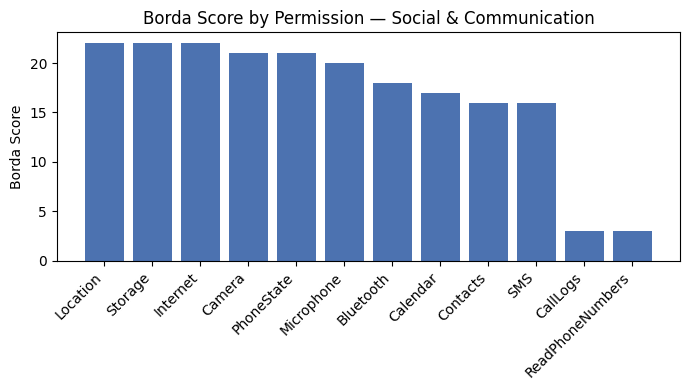

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(borda_a["Permission"], borda_a["BordaScore"], color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Borda Score")
plt.title("Borda Score by Permission — Social & Communication")
plt.tight_layout()
plt.show()

### Garrett Score

In [16]:
garrett_a = apply_garrett(ranking_a, N)
garrett_a[["Permission", "FrequencyRank", "PrivacyRank", "MaliciousRank", "GarrettTotal", "GarrettRank"]]

,Permission,FrequencyRank,PrivacyRank,MaliciousRank,GarrettTotal,GarrettRank
1,Location,4,9,1,166.944444,1
10,Internet,1,10,3,166.944444,1
4,Storage,2,8,4,163.000000,3
0,Camera,8,5,2,158.000000,4
9,PhoneState,3,7,5,157.500000,5
3,Microphone,7,1,8,156.944444,6
7,Bluetooth,9,2,7,143.000000,7
8,Calendar,10,3,6,137.500000,8
2,Contacts,5,6,9,132.500000,9
5,SMS,6,4,10,132.500000,9


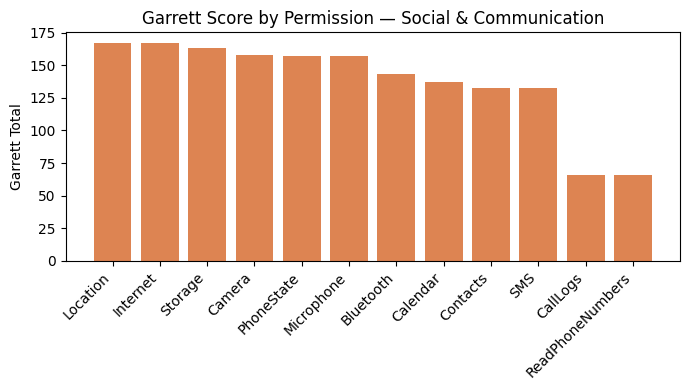

In [17]:
plt.figure(figsize=(7, 4))
plt.bar(garrett_a["Permission"], garrett_a["GarrettTotal"], color="#DD8452")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Garrett Total")
plt.title("Garrett Score by Permission — Social & Communication")
plt.tight_layout()
plt.show()

### Normalized Risk Weights

In [18]:
weights_a = normalize_weights(garrett_a)
weights_a

Permission
Location            0.101373
Internet            0.101373
Storage             0.098978
Camera              0.095942
PhoneState          0.095638
Microphone          0.095301
Bluetooth           0.086833
Calendar            0.083494
Contacts            0.080457
SMS                 0.080457
CallLogs            0.040077
ReadPhoneNumbers    0.040077
Name: GarrettTotal, dtype: float64

### Baseline Privacy Score & Classification

In [19]:
cat_a["BaselinePrivacyScore"] = baseline_score(cat_a, PERMISSIONS, weights_a)
cat_a["PrivacyClassification"] = cat_a["BaselinePrivacyScore"].apply(classify)
cat_a["PrivacyClassification"].value_counts()

PrivacyClassification
Low       1079
Medium     619
High        58
Name: count, dtype: int64

### Evaluation

In [20]:
metrics_a = evaluate(cat_a["LabelEncoded"], cat_a["BaselinePrivacyScore"])
pd.Series(metrics_a, name="Social & Communication")

Accuracy     0.362187
Precision    0.502415
Recall       0.092774
F1           0.156627
ROC-AUC      0.454732
Name: Social & Communication, dtype: float64

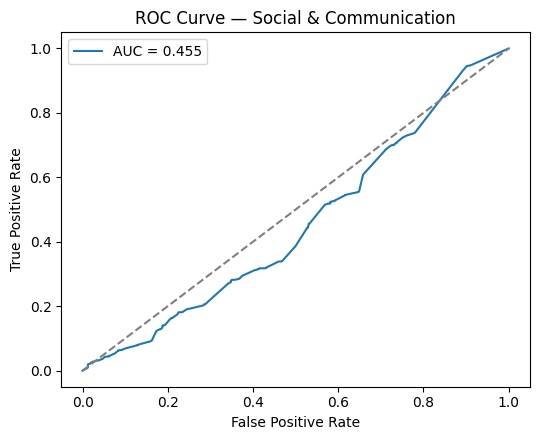

In [21]:
fpr_a, tpr_a, _ = roc_curve(cat_a["LabelEncoded"], cat_a["BaselinePrivacyScore"])
plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr_a, tpr_a, label=f"AUC = {metrics_a['ROC-AUC']:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Social & Communication")
plt.legend()
plt.tight_layout()
plt.show()

### Disagreement Rule

In [22]:
flagged_a = flag_disagreements(cat_a, cat_a["BaselinePrivacyScore"], FLAG_QUANTILE)
print(f"Flagged: {len(flagged_a)} apps ({len(flagged_a)/len(cat_a)*100:.1f}% of category)")
flagged_a.head(15)

Flagged: 294 apps (16.7% of category)


,App,Package,Category,TrueLabel,Score,Disagreement
1750,Tamil Unicode Keyboard-Donatio,com.KM.TK.DN,Communication,Malicious,0.0,1.0
2,RocketDial Language Pack,inteligeen.rocketdial.language,Communication,Malicious,0.0,1.0
1742,Tausug Public Affairs Phrases,com.robtheis.android.phrasebook.tx.pa,Communication,Malicious,0.0,1.0
14,Bucket Brigade Keyboard,com.bucketbrigade.softkeyboard,Communication,Malicious,0.0,1.0
1637,Tausug Civil Affairs Phrases,com.robtheis.android.phrasebook.tx.ca,Communication,Malicious,0.0,1.0
1550,GO SMS Pro Turkish package,com.jb.gosms.tr,Communication,Malicious,0.0,1.0
184,How to be Popular & get dates,com.ptajmarketing.ATeenagersGuid,Social,Malicious,0.0,1.0
149,Tamil Unicode Keyboard free,com.KM.TK,Communication,Malicious,0.0,1.0
1510,Handcent Font Pack5,com.handcent.fontpack.pack5,Communication,Malicious,0.0,1.0
1502,Turkmen Public Affairs Phrases,com.robtheis.android.phrasebook.ub.pa,Communication,Malicious,0.0,1.0


# Category B — Education & Reference

### Permission Rankings

In [23]:
ranking_b = compute_rankings(cat_b, PERMISSIONS)
ranking_b

,Permission,Frequency,FrequencyRank,PrivacyRisk,PrivacyRank,MaliciousRate,MaliciousRank
0,Camera,95,6,0.226667,5,0.768421,1
1,Location,482,4,0.158299,7,0.595436,9
2,Contacts,77,7,0.272294,2,0.597403,8
3,Microphone,109,5,0.187156,6,0.660550,5
4,Storage,1339,2,0.119467,9,0.690814,2
5,SMS,67,8,0.234328,4,0.641791,6
6,CallLogs,0,11,0.000000,11,0.000000,11
7,Bluetooth,8,10,0.250000,3,0.375000,10
8,Calendar,41,9,0.296748,1,0.682927,3
9,PhoneState,911,3,0.133992,8,0.678375,4


### Borda Score

In [24]:
borda_b = apply_borda(ranking_b, N)
borda_b[["Permission", "FrequencyRank", "PrivacyRank", "MaliciousRank", "BordaScore", "BordaRank"]]

,Permission,FrequencyRank,PrivacyRank,MaliciousRank,BordaScore,BordaRank
0,Camera,6,5,1,24,1
4,Storage,2,9,2,23,2
8,Calendar,9,1,3,23,2
9,PhoneState,3,8,4,21,4
3,Microphone,5,6,5,20,5
2,Contacts,7,2,8,19,6
5,SMS,8,4,6,18,7
10,Internet,1,10,7,18,7
1,Location,4,7,9,16,9
7,Bluetooth,10,3,10,13,10


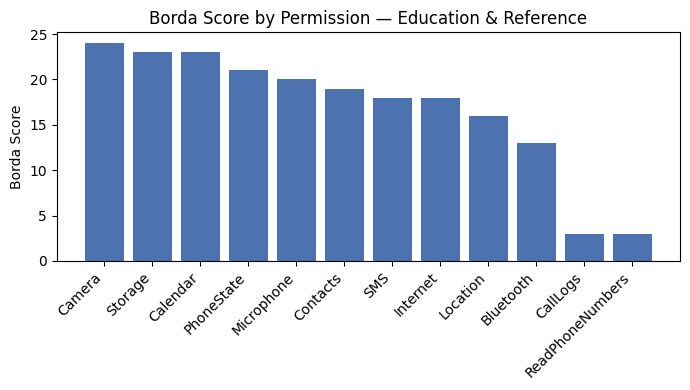

In [25]:
plt.figure(figsize=(7, 4))
plt.bar(borda_b["Permission"], borda_b["BordaScore"], color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Borda Score")
plt.title("Borda Score by Permission — Education & Reference")
plt.tight_layout()
plt.show()

### Garrett Score

In [26]:
garrett_b = apply_garrett(ranking_b, N)
garrett_b[["Permission", "FrequencyRank", "PrivacyRank", "MaliciousRank", "GarrettTotal", "GarrettRank"]]

,Permission,FrequencyRank,PrivacyRank,MaliciousRank,GarrettTotal,GarrettRank
0,Camera,6,5,1,176.944444,1
8,Calendar,9,1,3,171.944444,2
4,Storage,2,9,2,168.500000,3
9,PhoneState,3,8,4,157.500000,4
3,Microphone,5,6,5,152.500000,5
2,Contacts,7,2,8,148.000000,6
10,Internet,1,10,7,146.944444,7
5,SMS,8,4,6,142.500000,8
1,Location,4,7,9,132.500000,9
7,Bluetooth,10,3,10,117.500000,10


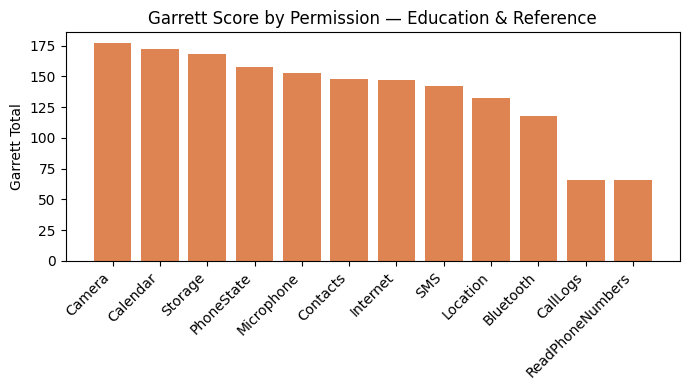

In [27]:
plt.figure(figsize=(7, 4))
plt.bar(garrett_b["Permission"], garrett_b["GarrettTotal"], color="#DD8452")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Garrett Total")
plt.title("Garrett Score by Permission — Education & Reference")
plt.tight_layout()
plt.show()

### Normalized Risk Weights

In [28]:
weights_b = normalize_weights(garrett_b)
weights_b

Permission
Camera              0.107445
Calendar            0.104409
Storage             0.102318
PhoneState          0.095638
Microphone          0.092602
Contacts            0.089869
Internet            0.089228
SMS                 0.086530
Location            0.080457
Bluetooth           0.071349
CallLogs            0.040077
ReadPhoneNumbers    0.040077
Name: GarrettTotal, dtype: float64

### Baseline Privacy Score & Classification

In [29]:
cat_b["BaselinePrivacyScore"] = baseline_score(cat_b, PERMISSIONS, weights_b)
cat_b["PrivacyClassification"] = cat_b["BaselinePrivacyScore"].apply(classify)
cat_b["PrivacyClassification"].value_counts()

PrivacyClassification
Low       2836
Medium     253
High        10
Name: count, dtype: int64

### Evaluation

In [30]:
metrics_b = evaluate(cat_b["LabelEncoded"], cat_b["BaselinePrivacyScore"])
pd.Series(metrics_b, name="Education & Reference")

Accuracy     0.338819
Precision    0.721311
Recall       0.021195
F1           0.041179
ROC-AUC      0.474412
Name: Education & Reference, dtype: float64

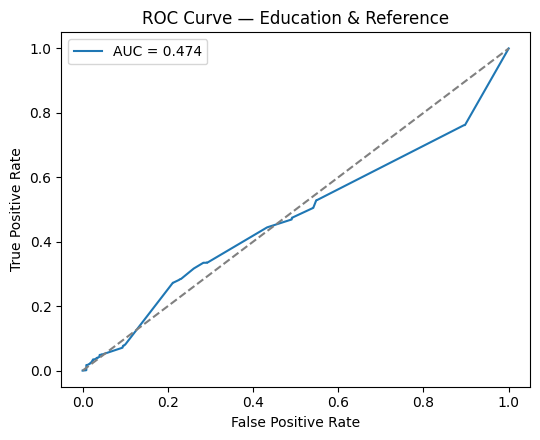

In [31]:
fpr_b, tpr_b, _ = roc_curve(cat_b["LabelEncoded"], cat_b["BaselinePrivacyScore"])
plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr_b, tpr_b, label=f"AUC = {metrics_b['ROC-AUC']:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Education & Reference")
plt.legend()
plt.tight_layout()
plt.show()

### Disagreement Rule

In [32]:
flagged_b = flag_disagreements(cat_b, cat_b["BaselinePrivacyScore"], FLAG_QUANTILE)
print(f"Flagged: {len(flagged_b)} apps ({len(flagged_b)/len(cat_b)*100:.1f}% of category)")
flagged_b.head(15)

Flagged: 494 apps (15.9% of category)


,App,Package,Category,TrueLabel,Score,Disagreement
3094,Human Nervous System Study Gui,com.mobilereference.nervoussystem,Books & Reference,Malicious,0.0,1.0
5,US Army Rifle Marksmanship,com.milodroid.riflemarksmanship,Books & Reference,Malicious,0.0,1.0
6,Manual of Military Training,com.myappbuilder.ManualofMilitaryTraining,Books & Reference,Malicious,0.0,1.0
11,The Divine Comedy. ILLUSTRATED,com.mobilereference.divinecomedy,Books & Reference,Malicious,0.0,1.0
13,2 Stroke Gas Oil Mix Calc Pro,pamplemousse.pro.gasoil,Books & Reference,Malicious,0.0,1.0
16,Heart of Deception,com.btgn.heartofdeception,Books & Reference,Malicious,0.0,1.0
20,Sound Touch,com.soundtouch,Education,Malicious,0.0,1.0
23,Works of Lord Byron,com.mobilereference.Byron,Books & Reference,Malicious,0.0,1.0
43,Torquemada en la Hoguera,com.libromovil.torquemada,Books & Reference,Malicious,0.0,1.0
50,Texas CDL Handbook,com.highridge.apdftxcdl,Books & Reference,Malicious,0.0,1.0


# Comparison

### Risk Weights

In [33]:
pd.DataFrame({CATEGORY_A: weights_a, CATEGORY_B: weights_b}).round(4)

,Social & Communication,Education & Reference
Permission,,
Bluetooth,0.0868,0.0713
Calendar,0.0835,0.1044
CallLogs,0.0401,0.0401
Camera,0.0959,0.1074
Contacts,0.0805,0.0899
Internet,0.1014,0.0892
Location,0.1014,0.0805
Microphone,0.0953,0.0926
PhoneState,0.0956,0.0956


### Evaluation Metrics

In [34]:
pd.DataFrame({CATEGORY_A: metrics_a, CATEGORY_B: metrics_b}).round(4)

,Social & Communication,Education & Reference
Accuracy,0.3622,0.3388
Precision,0.5024,0.7213
Recall,0.0928,0.0212
F1,0.1566,0.0412
ROC-AUC,0.4547,0.4744


### Disagreement Rule Summary

In [35]:
pd.DataFrame({
    CATEGORY_A: {"n_flagged": len(flagged_a), "pct_flagged": len(flagged_a)/len(cat_a)*100},
    CATEGORY_B: {"n_flagged": len(flagged_b), "pct_flagged": len(flagged_b)/len(cat_b)*100},
}).round(2)

,Social & Communication,Education & Reference
n_flagged,294.00,494.00
pct_flagged,16.74,15.94


### Note on accuracy

Both categories score well below the ~90% seen on the earlier synthetic dataset. This was
checked directly: in this real dataset, apps labeled Malicious request **fewer** dangerous
permissions on average than apps labeled Benign — the opposite of what a permission-based
risk score assumes. This is a real property of this dataset (possibly reflecting malware
that deliberately minimizes its permission footprint to evade detection), not a bug in this
notebook. The synthetic dataset scored ~90%+ because it was constructed so permissions
cleanly predict the label; this real dataset was not.